# Pipeline MCTNet — California + Arkansas (Table 2)
## ÉTAPE 1 : Alignement CDL → ÉTAPE 2 : Cube spectral 10 bandes → ÉTAPE 3 : MCT-Net
## Deux études de zone séparées dans le même notebook

> **Structure attendue :**
> ```
> data/
>   raw/
>     californiaX.SAFE
>     arkansasX.SAFE
>   processed/
>     cdl_california_2021.tif
>     cdl_arkansas_2021.tif
> models/
> ```


## 📦 Imports

In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling as WarpResampling
from rasterio.enums import Resampling
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi']        = 130
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid']         = True
plt.rcParams['grid.alpha']        = 0.4
plt.rcParams['grid.linestyle']    = '--'

print(f'PyTorch  : {torch.__version__}')
print(f'Rasterio : {rasterio.__version__}')
print(f'GPU dispo: {"✅ " + torch.cuda.get_device_name(0) if torch.cuda.is_available() else "⚠️  CPU uniquement"}')
print('✓ Imports OK')

PyTorch  : 2.11.0+cpu
Rasterio : 1.4.4
GPU dispo: ⚠️  CPU uniquement
✓ Imports OK


## ⚙️ Configuration — À MODIFIER selon ton projet

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# ⚙️  CONFIGURATION GLOBALE
# ══════════════════════════════════════════════════════════════════════════════

DATA_DIR      = Path('data')
SAFE_DIR      = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
MODEL_DIR     = Path('models')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Hyperparamètres communs ───────────────────────────────────────────────────
N_BANDS           = 10
BANDS_10M         = ['B02', 'B03', 'B04', 'B08']
BANDS_20M         = ['B05', 'B06', 'B07', 'B8A', 'B11', 'B12']
ALL_BANDS         = BANDS_10M + BANDS_20M
TOTAL_SAMPLES     = 10_000
N_TRAIN_PER_CLASS = 240
N_VAL_PER_CLASS   = 60
BATCH_SIZE        = 512
LR                = 0.0005
EPOCHS            = 50
RANDOM_STATE      = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# ══════════════════════════════════════════════════════════════════════════════
# 🌴 ZONE 1 — CALIFORNIA
# ══════════════════════════════════════════════════════════════════════════════
CDL_CA_INPUT = PROCESSED_DIR / 'cdl_california_2021.tif'
TRAIN_CSV_CA = PROCESSED_DIR / 'mctnet_california_10bands.csv'
MODEL_PATH_CA = MODEL_DIR / 'mctnet_california_final.pth'

CDL_ALIGNED_CA = {
    'SGH': PROCESSED_DIR / 'california_sgh.tif',
    'SFH': PROCESSED_DIR / 'california_sfh.tif',
    'SFG': PROCESSED_DIR / 'california_sfg.tif',
    'SFJ': PROCESSED_DIR / 'california_sfj.tif',
}

S2_REF_CA = {
    'SGH': SAFE_DIR / 'california1.SAFE/GRANULE/L2A_T10SGH_A022833_20210720T185324/IMG_DATA/R10m/T10SGH_20210720T183919_B04_10m.jp2',
    'SFH': SAFE_DIR / 'california10.SAFE/GRANULE/L2A_T10SFH_A022876_20210723T185617/IMG_DATA/R10m/T10SFH_20210723T184919_B04_10m.jp2',
    'SFG': SAFE_DIR / 'california8.SAFE/GRANULE/L2A_T10SFG_A022876_20210723T185617/IMG_DATA/R10m/T10SFG_20210723T184919_B04_10m.jp2',
    'SFJ': SAFE_DIR / 'california9.SAFE/GRANULE/L2A_T10SFJ_A022876_20210723T185617/IMG_DATA/R10m/T10SFJ_20210723T184919_B04_10m.jp2',
}

# ✅ FIX : zones SFG/SFJ corrigées
DATES_MAP_CA = {
    'july_sgh':  ('california1.SAFE',  'L2A_T10SGH_A022833_20210720T185324', 'T10SGH_20210720T183919', 'SGH'),
    'july_sgh2': ('california2.SAFE',  'L2A_T10SGH_A022833_20210720T185324', 'T10SGH_20210720T183919', 'SGH'),
    'jan_sgh':   ('california3.SAFE',  'L2A_T10SGH_A029239_20210126T184719', 'T10SGH_20210126T184641', 'SGH'),
    'sept_sgh':  ('california4.SAFE',  'L2A_T10SGH_A023734_20210921T185231', 'T10SGH_20210921T184959', 'SGH'),
    'jan_sfg':   ('california5.SAFE',  'L2A_T10SFG_A029239_20210126T184719', 'T10SFG_20210126T184641', 'SFG'),
    'sept_sfg':  ('california6.SAFE',  'L2A_T10SFG_A032714_20210926T185622', 'T10SFG_20210926T185131', 'SFG'),
    'apr_sfg':   ('california7.SAFE',  'L2A_T10SFG_A030426_20210419T190327', 'T10SFG_20210419T184911', 'SFG'),
    'july_sfg':  ('california8.SAFE',  'L2A_T10SFG_A022876_20210723T185617', 'T10SFG_20210723T184919', 'SFG'),
    'july_sfj':  ('california9.SAFE',  'L2A_T10SFJ_A022876_20210723T185617', 'T10SFJ_20210723T184919', 'SFJ'),
    'july_sfh':  ('california10.SAFE', 'L2A_T10SFH_A022876_20210723T185617', 'T10SFH_20210723T184919', 'SFH'),
}

CA_CLASSES = {
    'Grapes'    : [87, 214, 217, 239, 241, 242, 245, 246, 250, 252],
    'Rice'      : [3, 238],
    'Alfalfa'   : [36, 225, 240],
    'Almonds'   : [68, 243, 254],
    'Pistachios': [76, 204, 244],
}
CA_ORDER    = ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others']
N_CLASSES_CA = len(CA_ORDER)

# ══════════════════════════════════════════════════════════════════════════════
# 🌾 ZONE 2 — ARKANSAS
# ══════════════════════════════════════════════════════════════════════════════
CDL_AR_INPUT  = PROCESSED_DIR / 'cdl_arkansas_2021.tif'
TRAIN_CSV_AR  = PROCESSED_DIR / 'mctnet_arkansas_10bands.csv'
MODEL_PATH_AR = MODEL_DIR / 'mctnet_arkansas_final.pth'

CDL_ALIGNED_AR = {
    'SXU': PROCESSED_DIR / 'arkansas_sxu.tif',
}

S2_REF_AR = {
    # ⚠️  Remplace FILE_PREFIX par le préfixe réel de tes fichiers jp2
    # Ex: 'T15SXU_20210927T165016'
    'SXU': SAFE_DIR / 'arkansas1.SAFE/GRANULE/L2A_T15SXU_A032727_20210927T165058/IMG_DATA/R10m/T15SXU_20210927T164051_B04_10m.jp2',
}

# ⚠️  Remplis les granule_dir et file_prefix pour chaque date Arkansas
# Format : (safe_dir, granule_dir, file_prefix, zone)
DATES_MAP_AR = {
    'sept_ar1': ('arkansas1.SAFE', 'L2A_T15SXU_A032727_20210927T165058', 'T15SXU_20210927T164051', 'SXU'),
    'sept_ar2': ('arkansas2.SAFE', 'L2A_T15SXU_A032727_20210927T165058', 'T15SXU_20210927T164051', 'SXU'),
    'apr_ar3':  ('arkansas3.SAFE', 'L2A_T15SXU_A021602_20210425T164719', 'T15SXU_20210425T163829', 'SXU'),
    'jan_ar4':  ('arkansas4.SAFE', 'L2A_T15SXU_A020215_20210118T170017', 'T15SXU_20210118T165629', 'SXU'),
}

AR_CLASSES = {
    'Rice'    : [3, 238],
    'Soybeans': [5],
    'Cotton'  : [2],
    'Corn'    : [1],
}
AR_ORDER    = ['Rice', 'Soybeans', 'Cotton', 'Corn', 'Others']
N_CLASSES_AR = len(AR_ORDER)

# ── Résumé ────────────────────────────────────────────────────────────────────
print('=== Configuration ===')
print(f'  Device  : {DEVICE}')
print(f'  Bandes  : {ALL_BANDS}')
print(f'\n  [CA] Dates   : {list(DATES_MAP_CA.keys())}')
print(f'  [CA] Classes : {CA_ORDER}')
print(f'  [CA] CDL     : {"✅" if CDL_CA_INPUT.exists() else "❌ INTROUVABLE"} {CDL_CA_INPUT}')
print(f'\n  [AR] Dates   : {list(DATES_MAP_AR.keys())}')
print(f'  [AR] Classes : {AR_ORDER}')
print(f'  [AR] CDL     : {"✅" if CDL_AR_INPUT.exists() else "❌ INTROUVABLE"} {CDL_AR_INPUT}')


=== Configuration ===
  Device  : cpu
  Bandes  : ['B02', 'B03', 'B04', 'B08', 'B05', 'B06', 'B07', 'B8A', 'B11', 'B12']

  [CA] Dates   : ['july_sgh', 'july_sgh2', 'jan_sgh', 'sept_sgh', 'jan_sfg', 'sept_sfg', 'apr_sfg', 'july_sfg', 'july_sfj', 'july_sfh']
  [CA] Classes : ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others']
  [CA] CDL     : ✅ data\processed\cdl_california_2021.tif

  [AR] Dates   : ['sept_ar1', 'sept_ar2', 'apr_ar3', 'jan_ar4']
  [AR] Classes : ['Rice', 'Soybeans', 'Cotton', 'Corn', 'Others']
  [AR] CDL     : ✅ data\processed\cdl_arkansas_2021.tif


---
# ÉTAPE 1 — Alignement CDL
### ✅ FIX : Alignement sur DEUX grilles distinctes (SGH et SFH)

In [3]:
import gc
gc.collect()

def align_cdl_to_s2(s2_ref_path, cdl_input_path, output_path, zone_name):
    """Reprojette le CDL sur la grille exacte d'une tuile Sentinel-2."""
    if not Path(s2_ref_path).exists():
        print(f'  ⚠️  Bande réf introuvable pour {zone_name} — SKIP')
        return None, None, None
    print(f'=== Alignement CDL Zone {zone_name} ===')
    with rasterio.open(s2_ref_path) as s2:
        dst_crs = s2.crs; dst_transform = s2.transform
        profile = s2.profile.copy()
        print(f'  CRS: {dst_crs}  |  Bounds: {s2.bounds}')
    profile.update({'dtype': 'uint16', 'count': 1, 'nodata': 0, 'driver': 'GTiff'})
    if output_path.exists(): output_path.unlink()
    with rasterio.open(cdl_input_path) as src:
        with rasterio.open(output_path, 'w', **profile) as dst:
            reproject(source=rasterio.band(src, 1), destination=rasterio.band(dst, 1),
                      src_transform=src.transform, src_crs=src.crs,
                      dst_transform=dst_transform, dst_crs=dst_crs,
                      resampling=WarpResampling.nearest)
    print(f'✅ CDL {zone_name} aligné → {output_path}\n')
    return profile, dst_transform, dst_crs

def align_all_zones(s2_ref_dict, cdl_input_path, cdl_aligned_dict, label):
    """Aligne le CDL sur toutes les zones d'une étude."""
    print(f'\n{"="*60}')
    print(f'  Alignement CDL — {label}')
    print(f'{"="*60}')
    profiles = {}
    for zone in sorted(s2_ref_dict.keys()):
        p, t, c = align_cdl_to_s2(s2_ref_dict[zone], cdl_input_path, cdl_aligned_dict[zone], zone)
        profiles[zone] = {'ok': p is not None, 'profile': p, 'transform': t, 'crs': c}
    return profiles

# ── California ────────────────────────────────────────────────────────────────
zone_profiles_CA = align_all_zones(S2_REF_CA, CDL_CA_INPUT, CDL_ALIGNED_CA, 'CALIFORNIA')

# ── Arkansas ──────────────────────────────────────────────────────────────────
zone_profiles_AR = align_all_zones(S2_REF_AR, CDL_AR_INPUT, CDL_ALIGNED_AR, 'ARKANSAS')

print('\n=== Résumé alignement ===')
for zone, info in zone_profiles_CA.items(): print(f'  CA-{zone}: {"✅" if info["ok"] else "❌"}')
for zone, info in zone_profiles_AR.items(): print(f'  AR-{zone}: {"✅" if info["ok"] else "❌"}')



  Alignement CDL — CALIFORNIA
=== Alignement CDL Zone SFG ===
  CRS: EPSG:32610  |  Bounds: BoundingBox(left=600000.0, bottom=4090200.0, right=709800.0, top=4200000.0)
✅ CDL SFG aligné → data\processed\california_sfg.tif

=== Alignement CDL Zone SFH ===
  CRS: EPSG:32610  |  Bounds: BoundingBox(left=600000.0, bottom=4190220.0, right=709800.0, top=4300020.0)
✅ CDL SFH aligné → data\processed\california_sfh.tif

=== Alignement CDL Zone SFJ ===
  CRS: EPSG:32610  |  Bounds: BoundingBox(left=600000.0, bottom=4290240.0, right=709800.0, top=4400040.0)
✅ CDL SFJ aligné → data\processed\california_sfj.tif

=== Alignement CDL Zone SGH ===
  CRS: EPSG:32610  |  Bounds: BoundingBox(left=699960.0, bottom=4190220.0, right=809760.0, top=4300020.0)
✅ CDL SGH aligné → data\processed\california_sgh.tif


  Alignement CDL — ARKANSAS
=== Alignement CDL Zone SXU ===
  CRS: EPSG:32615  |  Bounds: BoundingBox(left=600000.0, bottom=3790200.0, right=709800.0, top=3900000.0)
✅ CDL SXU aligné → data\processed\

### 🔍 Inspection du CDL aligné

=== California (Zone SGH) ===
  CRS: EPSG:32610  |  Taille: 10980×10980 px
  Classes agricoles: 55  |  Pixels: 120,560,400


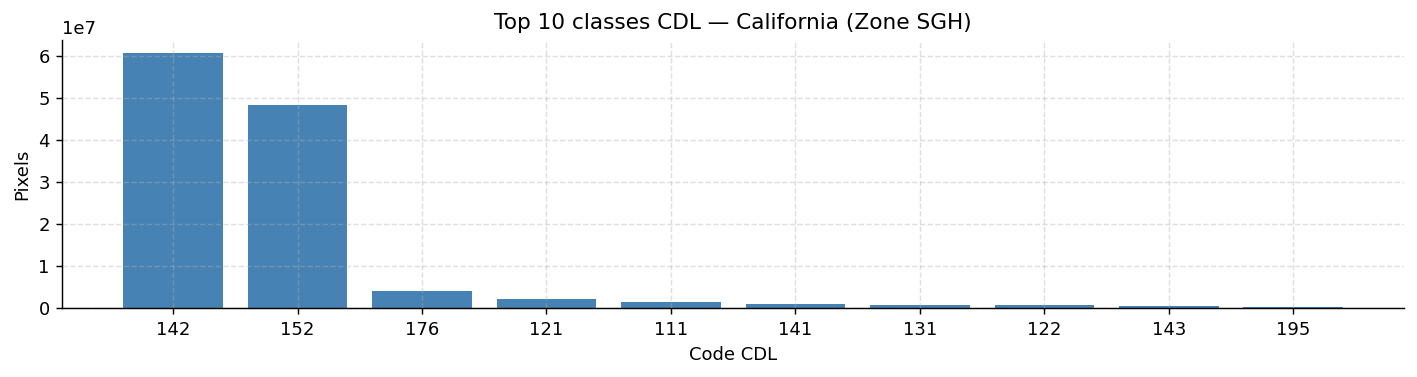

=== Arkansas (Zone SXU) ===
  CRS: EPSG:32615  |  Taille: 10980×10980 px
  Classes agricoles: 43  |  Pixels: 119,683,812


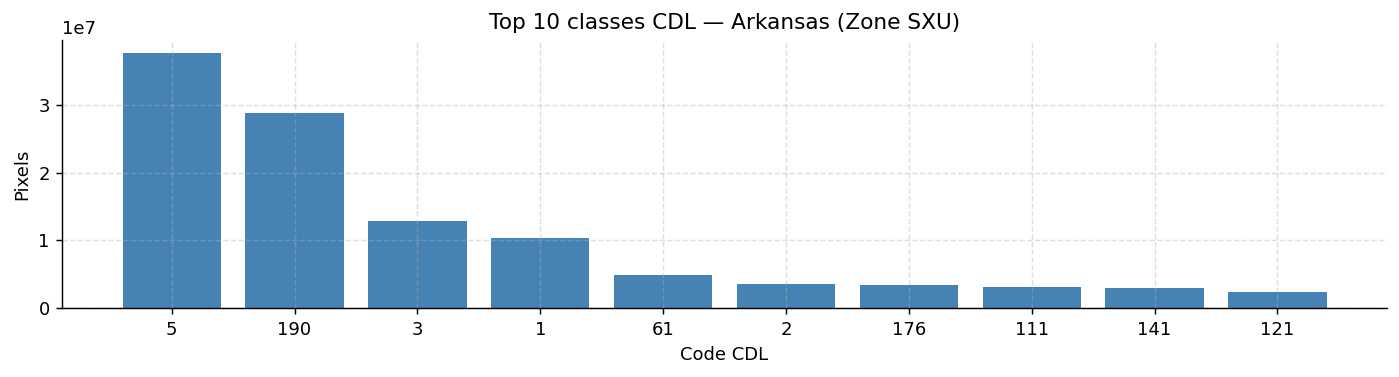

✅ Inspection CDL terminée


In [4]:
def inspect_cdl(cdl_path, title):
    with rasterio.open(cdl_path) as dst:
        print(f'=== {title} ===')
        print(f'  CRS: {dst.crs}  |  Taille: {dst.width}×{dst.height} px')
        data = dst.read(1)
    uniq, cnt = np.unique(data[data > 0], return_counts=True)
    print(f'  Classes agricoles: {len(uniq)}  |  Pixels: {cnt.sum():,}')
    fig, ax = plt.subplots(figsize=(11, 3))
    top10 = sorted(zip(cnt, uniq), reverse=True)[:10]
    tc, tk = zip(*top10)
    ax.bar([str(int(c)) for c in tk], tc, color='steelblue')
    ax.set_title(f'Top 10 classes CDL — {title}')
    ax.set_xlabel('Code CDL'); ax.set_ylabel('Pixels')
    plt.tight_layout(); plt.show()

inspect_cdl(CDL_ALIGNED_CA['SGH'], 'California (Zone SGH)')
if zone_profiles_AR['SXU']['ok']:
    inspect_cdl(CDL_ALIGNED_AR['SXU'], 'Arkansas (Zone SXU)')
print('✅ Inspection CDL terminée')


---
# ÉTAPE 2 — Échantillonnage 10 000 pixels (Table 2)
### ✅ FIX : `Nb of Samples` = total sélectionné (train+val+test), pas les pixels disponibles

In [5]:
def build_code_to_class(classes_dict):
    """Construit le mapping code CDL → nom de classe."""
    mapping = {}
    for name, codes in classes_dict.items():
        for c in codes:
            mapping[c] = name
    return mapping

CODE_TO_CLASS_CA = build_code_to_class(CA_CLASSES)
CODE_TO_CLASS_AR = build_code_to_class(AR_CLASSES)

print('Classes California :', list(CA_CLASSES.keys()) + ['Others'])
print('Classes Arkansas   :', list(AR_CLASSES.keys()) + ['Others'])


Classes California : ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others']
Classes Arkansas   : ['Rice', 'Soybeans', 'Cotton', 'Corn', 'Others']


In [6]:
def extract_pixels_by_zone(cdl_path):
    """Retourne rows, cols, labels (numpy arrays) et shape pour une zone."""
    with rasterio.open(cdl_path) as src:
        labels = src.read(1)
    mask = labels > 0
    rows, cols = np.where(mask)
    return rows, cols, labels[rows, cols], labels.shape

def build_class_data(cdl_aligned_dict, zone_profiles, code_to_class, order):
    """
    Extrait les pixels par classe pour toutes les zones d'une étude.
    Retourne un dict {cls: {rows, cols, zones}} en numpy.
    """
    zone_data = {}
    for zone, info in zone_profiles.items():
        if info['ok']:
            r, c, l, sh = extract_pixels_by_zone(cdl_aligned_dict[zone])
            zone_data[zone] = {'rows': r, 'cols': c, 'labels': l, 'shape': sh}
            print(f'  Zone {zone}: {len(r):,} pixels agricoles (grille {sh})')
        else:
            print(f'  Zone {zone}: ⚠️ non disponible')

    class_data = {cls: {'rows': [], 'cols': [], 'zones': []} for cls in order}
    for zone, zd in zone_data.items():
        lbl_int = zd['labels'].astype(np.int32)
        for code in np.unique(lbl_int):
            cls  = code_to_class.get(int(code), 'Others')
            mask = lbl_int == code
            class_data[cls]['rows'].append(zd['rows'][mask])
            class_data[cls]['cols'].append(zd['cols'][mask])
            class_data[cls]['zones'].append(np.full(mask.sum(), zone))

    for cls in order:
        d = class_data[cls]
        class_data[cls]['rows']  = np.concatenate(d['rows'])  if d['rows']  else np.array([], dtype=np.int64)
        class_data[cls]['cols']  = np.concatenate(d['cols'])  if d['cols']  else np.array([], dtype=np.int64)
        class_data[cls]['zones'] = np.concatenate(d['zones']) if d['zones'] else np.array([], dtype=str)

    return class_data, zone_data

print('=== Extraction pixels — California ===')
class_data_CA, zone_data_CA = build_class_data(CDL_ALIGNED_CA, zone_profiles_CA, CODE_TO_CLASS_CA, CA_ORDER)
print('\nPixels disponibles par classe [CA]:')
for cls in CA_ORDER:
    n = len(class_data_CA[cls]['rows'])
    ok = '✅' if n >= N_TRAIN_PER_CLASS + N_VAL_PER_CLASS + 1 else '❌ INSUFFISANT'
    print(f'  {ok}  {cls:<12}: {n:>12,} px')

print('\n=== Extraction pixels — Arkansas ===')
class_data_AR, zone_data_AR = build_class_data(CDL_ALIGNED_AR, zone_profiles_AR, CODE_TO_CLASS_AR, AR_ORDER)
print('\nPixels disponibles par classe [AR]:')
for cls in AR_ORDER:
    n = len(class_data_AR[cls]['rows'])
    ok = '✅' if n >= N_TRAIN_PER_CLASS + N_VAL_PER_CLASS + 1 else '❌ INSUFFISANT'
    print(f'  {ok}  {cls:<12}: {n:>12,} px')


=== Extraction pixels — California ===
  Zone SFG: 120,560,400 pixels agricoles (grille (10980, 10980))
  Zone SFH: 120,560,400 pixels agricoles (grille (10980, 10980))
  Zone SFJ: 120,560,400 pixels agricoles (grille (10980, 10980))
  Zone SGH: 120,560,400 pixels agricoles (grille (10980, 10980))

Pixels disponibles par classe [CA]:
  ✅  Grapes      :       44,331 px
  ✅  Rice        :    9,998,323 px
  ✅  Alfalfa     :   12,182,065 px
  ✅  Almonds     :      271,855 px
  ✅  Pistachios  :   10,848,945 px
  ✅  Others      :  448,896,081 px

=== Extraction pixels — Arkansas ===
  Zone SXU: 119,683,812 pixels agricoles (grille (10980, 10980))

Pixels disponibles par classe [AR]:
  ✅  Rice        :   12,861,658 px
  ✅  Soybeans    :   37,757,161 px
  ✅  Cotton      :    3,560,759 px
  ✅  Corn        :   10,419,524 px
  ✅  Others      :   55,084,710 px


In [7]:
def sample_pixels(class_data, order, n_classes, rng_seed=RANDOM_STATE):
    """Échantillonne exactement TOTAL_SAMPLES pixels avec split train/val/test."""
    rng = np.random.default_rng(rng_seed)
    N_MIN = N_TRAIN_PER_CLASS + N_VAL_PER_CLASS + 1
    test_budget = TOTAL_SAMPLES - n_classes * (N_TRAIN_PER_CLASS + N_VAL_PER_CLASS)
    cuts = np.sort(rng.choice(test_budget - n_classes + 1, n_classes - 1, replace=False))
    cuts = np.concatenate([[0], cuts + np.arange(1, n_classes), [test_budget]])
    test_sizes = np.diff(cuts).astype(int)

    all_rows, all_cols, all_zones, all_labels, all_splits = [], [], [], [], []
    table_rows = []
    total_count = 0

    for k, cls in enumerate(order):
        d = class_data[cls]
        n_avail = len(d['rows'])
        n_test  = min(int(test_sizes[k]), n_avail - N_TRAIN_PER_CLASS - N_VAL_PER_CLASS)
        if n_avail < N_MIN:
            print(f'  ⚠️  {cls} ignorée ({n_avail} px < {N_MIN} minimum)')
            continue
        idx    = rng.permutation(n_avail)
        tr_idx = idx[:N_TRAIN_PER_CLASS]
        v_idx  = idx[N_TRAIN_PER_CLASS:N_TRAIN_PER_CLASS + N_VAL_PER_CLASS]
        te_idx = idx[N_TRAIN_PER_CLASS + N_VAL_PER_CLASS:N_TRAIN_PER_CLASS + N_VAL_PER_CLASS + n_test]
        for sidx, split_name in [(tr_idx,'train'),(v_idx,'val'),(te_idx,'test')]:
            n = len(sidx)
            all_rows.append(d['rows'][sidx]); all_cols.append(d['cols'][sidx])
            all_zones.append(d['zones'][sidx]); all_labels.append(np.full(n, cls))
            all_splits.append(np.full(n, split_name))
        class_total = N_TRAIN_PER_CLASS + N_VAL_PER_CLASS + n_test
        total_count += class_total
        table_rows.append({'Class Name': cls, 'Nb of Samples': class_total,
                           'Training': N_TRAIN_PER_CLASS, 'Validation': N_VAL_PER_CLASS,
                           'Testing': n_test})

    df_rec = pd.DataFrame({
        'row': np.concatenate(all_rows), 'col': np.concatenate(all_cols),
        'zone': np.concatenate(all_zones), 'label': np.concatenate(all_labels),
        'split': np.concatenate(all_splits),
    })
    return df_rec, table_rows, total_count

print('=== Échantillonnage California ===')
df_records_CA, table_rows_CA, total_CA = sample_pixels(class_data_CA, CA_ORDER, N_CLASSES_CA)
print(f'✅ CA Total : {total_CA:,} px  | Train:{(df_records_CA["split"]=="train").sum()} Val:{(df_records_CA["split"]=="val").sum()} Test:{(df_records_CA["split"]=="test").sum()}')

print('\n=== Échantillonnage Arkansas ===')
df_records_AR, table_rows_AR, total_AR = sample_pixels(class_data_AR, AR_ORDER, N_CLASSES_AR, rng_seed=RANDOM_STATE+1)
print(f'✅ AR Total : {total_AR:,} px  | Train:{(df_records_AR["split"]=="train").sum()} Val:{(df_records_AR["split"]=="val").sum()} Test:{(df_records_AR["split"]=="test").sum()}')


=== Échantillonnage California ===
✅ CA Total : 10,000 px  | Train:1440 Val:360 Test:8200

=== Échantillonnage Arkansas ===
✅ AR Total : 10,000 px  | Train:1200 Val:300 Test:8500


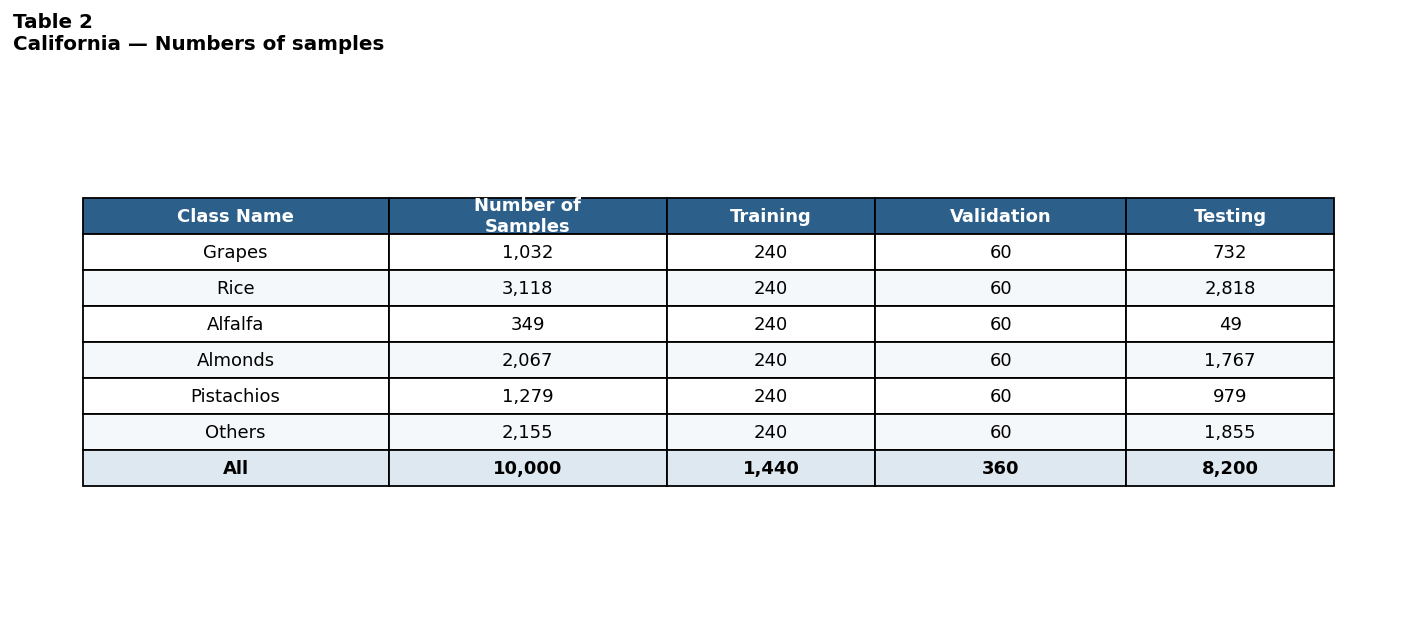

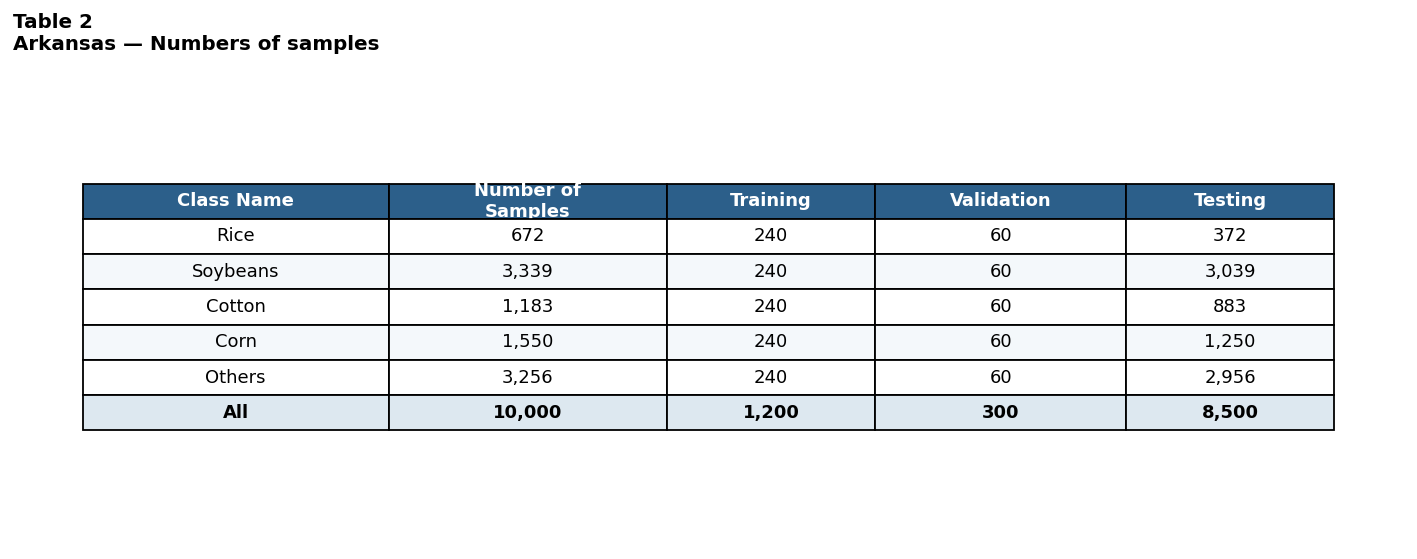

In [8]:
def display_table2(table_rows, title):
    df_t = pd.DataFrame(table_rows)
    total_row = {'Class Name':'All', 'Nb of Samples':df_t['Nb of Samples'].sum(),
                 'Training':df_t['Training'].sum(), 'Validation':df_t['Validation'].sum(),
                 'Testing':df_t['Testing'].sum()}
    df_d = pd.concat([df_t, pd.DataFrame([total_row])], ignore_index=True)
    fig, ax = plt.subplots(figsize=(11, 0.55*(len(df_d)+2)))
    ax.axis('off')
    col_labels = ['Class Name','Number of\nSamples','Training','Validation','Testing']
    col_widths = [0.22, 0.20, 0.15, 0.18, 0.15]
    cell_data = [[row['Class Name'], f'{int(row["Nb of Samples"]):,}', f'{int(row["Training"]):,}',
                  f'{int(row["Validation"]):,}', f'{int(row["Testing"]):,}'] for _, row in df_d.iterrows()]
    tbl = ax.table(cellText=cell_data, colLabels=col_labels, colWidths=col_widths, loc='center', cellLoc='center')
    tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.5)
    for j in range(len(col_labels)):
        tbl[0,j].set_facecolor('#2c5f8a'); tbl[0,j].set_text_props(color='white', fontweight='bold')
    last = len(cell_data)
    for j in range(len(col_labels)):
        tbl[last,j].set_facecolor('#dde8f0'); tbl[last,j].set_text_props(fontweight='bold')
    for i in range(1, last):
        c = '#f4f8fb' if i%2==0 else 'white'
        for j in range(len(col_labels)): tbl[i,j].set_facecolor(c)
    ax.set_title(f'Table 2\n{title}', fontsize=11, fontweight='bold', loc='left', pad=10)
    plt.tight_layout(); plt.show()

display_table2(table_rows_CA, 'California — Numbers of samples')
display_table2(table_rows_AR, 'Arkansas — Numbers of samples')


---
# ÉTAPE 2b — Extraction spectrale
### 🔧 Fonction get_band_path

In [9]:
def get_band_path(safe_dir_name, granule_dir, file_prefix, band, res):
    dir_path = SAFE_DIR / safe_dir_name / 'GRANULE' / granule_dir / 'IMG_DATA' / f'R{res}m'
    return dir_path / f'{file_prefix}_{band}_{res}m.jp2'

print('Vérification bandes B04 — California :')
for date_name, (safe_dir, granule_dir, file_prefix, zone) in DATES_MAP_CA.items():
    path = get_band_path(safe_dir, granule_dir, file_prefix, 'B04', 10)
    print(f'  {"✅" if path.exists() else "❌"} {date_name:12} [{zone}] → {path.name}')

print('\nVérification bandes B04 — Arkansas :')
for date_name, (safe_dir, granule_dir, file_prefix, zone) in DATES_MAP_AR.items():
    path = get_band_path(safe_dir, granule_dir, file_prefix, 'B04', 10)
    print(f'  {"✅" if path.exists() else "❌ (vérifier placeholder)"} {date_name:12} [{zone}] → {path.name}')


Vérification bandes B04 — California :
  ✅ july_sgh     [SGH] → T10SGH_20210720T183919_B04_10m.jp2
  ✅ july_sgh2    [SGH] → T10SGH_20210720T183919_B04_10m.jp2
  ✅ jan_sgh      [SGH] → T10SGH_20210126T184641_B04_10m.jp2
  ✅ sept_sgh     [SGH] → T10SGH_20210921T184959_B04_10m.jp2
  ✅ jan_sfg      [SFG] → T10SFG_20210126T184641_B04_10m.jp2
  ✅ sept_sfg     [SFG] → T10SFG_20210926T185131_B04_10m.jp2
  ✅ apr_sfg      [SFG] → T10SFG_20210419T184911_B04_10m.jp2
  ✅ july_sfg     [SFG] → T10SFG_20210723T184919_B04_10m.jp2
  ✅ july_sfj     [SFJ] → T10SFJ_20210723T184919_B04_10m.jp2
  ✅ july_sfh     [SFH] → T10SFH_20210723T184919_B04_10m.jp2

Vérification bandes B04 — Arkansas :
  ✅ sept_ar1     [SXU] → T15SXU_20210927T164051_B04_10m.jp2
  ✅ sept_ar2     [SXU] → T15SXU_20210927T164051_B04_10m.jp2
  ✅ apr_ar3      [SXU] → T15SXU_20210425T163829_B04_10m.jp2
  ✅ jan_ar4      [SXU] → T15SXU_20210118T165629_B04_10m.jp2


In [10]:
def extract_spectral(df_records, dates_map, zone_profiles, zone_data, label):
    """
    Extrait les 10 bandes × N_DATES pour chaque pixel.
    Retourne feat_matrix (numpy) et feat_names (list).
    """
    print(f'\n{"="*60}')
    print(f'  Extraction spectrale — {label}')
    print(f'{"="*60}')

    all_zones = sorted(set(v[3] for v in dates_map.values()))
    zone_masks = {z: (df_records['zone'] == z).values for z in all_zones}
    zone_rows  = {z: df_records['row'].values[zone_masks[z]] for z in all_zones}
    zone_cols  = {z: df_records['col'].values[zone_masks[z]] for z in all_zones}

    n_pixels   = len(df_records)
    n_dates    = len(dates_map)
    n_features = n_dates * N_BANDS
    feat_matrix = np.full((n_pixels, n_features), np.nan, dtype=np.float32)
    feat_names  = []
    col_idx = 0

    for date_name, (safe_dir_name, granule_dir, file_prefix, zone) in dates_map.items():
        print(f'\n📅 {date_name.upper()} [{zone}]')
        if not zone_profiles.get(zone, {}).get('ok', False):
            print(f'  ⚠️ Zone {zone} non alignée — NaN')
            for band in ALL_BANDS:
                feat_names.append(f'{band}_{date_name}'); col_idx += 1
            continue

        zmask  = zone_masks[zone]
        rows_z = zone_rows[zone]
        cols_z = zone_cols[zone]
        shape_z = zone_data[zone]['shape']

        if zmask.sum() == 0:
            print('  ⚠️ Aucun pixel — skip')
            for band in ALL_BANDS:
                feat_names.append(f'{band}_{date_name}'); col_idx += 1
            continue

        # ── ✅ MASQUE NUAGE via SCL (Sentinel-2 Scene Classification Layer) ──────
        # Classes SCL nuageuses : 3=ombre nuage, 8=nuage moyen, 9=nuage épais, 10=cirrus
        SCL_CLOUD_CLASSES = {3, 8, 9, 10}
        cloud_mask = np.zeros(shape_z, dtype=bool)  # True = nuageux
        scl_dir  = SAFE_DIR / safe_dir_name / 'GRANULE' / granule_dir / 'IMG_DATA' / 'R20m'
        scl_path = scl_dir / f'{file_prefix}_SCL_20m.jp2'
        if scl_path.exists():
            with rasterio.open(scl_path) as scl_src:
                scl_data = scl_src.read(1, out_shape=shape_z, resampling=Resampling.nearest)
            for cls in SCL_CLOUD_CLASSES:
                cloud_mask |= (scl_data == cls)
            n_cloudy = cloud_mask[rows_z, cols_z].sum()
            print(f'  ☁️  SCL chargé — {n_cloudy}/{zmask.sum()} pixels nuageux masqués')
        else:
            print(f'  ⚠️  SCL introuvable ({scl_path.name}) — pas de masque nuage')

        # Pixels nuageux dans cette zone → NaN pour toutes les bandes de cette date
        cloudy_pixels = cloud_mask[rows_z, cols_z]  # bool array, len = nb pixels de la zone

        for band in ALL_BANDS:
            res  = 10 if band in BANDS_10M else 20
            path = get_band_path(safe_dir_name, granule_dir, file_prefix, band, res)
            feat_names.append(f'{band}_{date_name}')
            if not path.exists():
                print(f'  ❌ {band}', end=' | '); col_idx += 1; continue
            with rasterio.open(path) as src:
                data = src.read(1, out_shape=shape_z, resampling=Resampling.bilinear)
                values = data[rows_z, cols_z].astype(np.float32)
                values[cloudy_pixels] = np.nan  # ✅ NaN sur les pixels nuageux
                feat_matrix[zmask, col_idx] = values
            print(f'  ✅ {band}', end=' | ')
            col_idx += 1
        print()

    nan_pct = 100 * np.isnan(feat_matrix).sum() / (n_pixels * n_features)
    print(f'\n  {label} — {n_pixels} pixels × {len(feat_names)} features | NaN: {nan_pct:.1f}%')
    return feat_matrix, feat_names

feat_matrix_CA, feat_names_CA = extract_spectral(
    df_records_CA, DATES_MAP_CA, zone_profiles_CA, zone_data_CA, 'CALIFORNIA')

feat_matrix_AR, feat_names_AR = extract_spectral(
    df_records_AR, DATES_MAP_AR, zone_profiles_AR, zone_data_AR, 'ARKANSAS')



  Extraction spectrale — CALIFORNIA

📅 JULY_SGH [SGH]
  ☁️  SCL chargé — 26/727 pixels nuageux masqués
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 JULY_SGH2 [SGH]
  ☁️  SCL chargé — 26/727 pixels nuageux masqués
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 JAN_SGH [SGH]
  ☁️  SCL chargé — 27/727 pixels nuageux masqués
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 SEPT_SGH [SGH]
  ☁️  SCL chargé — 0/727 pixels nuageux masqués
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 JAN_SFG [SFG]
  ☁️  SCL chargé — 33/2387 pixels nuageux masqués
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 SEPT_SFG [SFG]
  ☁️  SCL chargé — 1/2387 pixels nuageux masqués
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06

In [11]:
def save_csv(feat_matrix, feat_names, df_records, csv_path, label):
    df_out = pd.DataFrame(feat_matrix, columns=feat_names)
    df_out.insert(0, 'crop_label', df_records['label'].values)
    df_out.insert(1, 'split',      df_records['split'].values)
    df_out.to_csv(csv_path, index=False)
    size_mb = csv_path.stat().st_size / 1e6
    print(f'✅ [{label}] CSV sauvegardé : {csv_path}  ({size_mb:.1f} MB)')
    print(f'   {len(df_out):,} pixels × {df_out.shape[1]} colonnes')

save_csv(feat_matrix_CA, feat_names_CA, df_records_CA, TRAIN_CSV_CA, 'California')
save_csv(feat_matrix_AR, feat_names_AR, df_records_AR, TRAIN_CSV_AR, 'Arkansas')


✅ [California] CSV sauvegardé : data\processed\mctnet_california_10bands.csv  (2.2 MB)
   10,000 pixels × 102 colonnes
✅ [Arkansas] CSV sauvegardé : data\processed\mctnet_arkansas_10bands.csv  (2.7 MB)
   10,000 pixels × 42 colonnes


---
# ÉTAPE 3 — MCT-Net
### ✅ FIX : split Train/Val/Test depuis la colonne 'split' (pas sklearn random split)

In [12]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

def load_and_prepare(csv_path, dates_map, label):
    """Charge le CSV, nettoie les NaN, normalise, retourne loaders + méta."""
    print(f'\n{"="*60}')
    print(f'  Chargement — {label}')
    print(f'{"="*60}')
    df = pd.read_csv(csv_path)
    print(f'  Lignes: {len(df):,}  |  Colonnes: {df.shape[1]}')
    print(f'  Classes: {df["crop_label"].nunique()}  |  Split: {df["split"].value_counts().to_dict()}')

    le = LabelEncoder()
    df['label_encoded'] = le.fit_transform(df['crop_label'])
    num_classes = len(le.classes_)
    print(f'  Classes encodées: {list(le.classes_)}')

    feat_cols = [c for c in df.columns if c not in ['crop_label','split','label_encoded']]
    n_dates   = len(dates_map)

    # ✅ Fix NaN : médiane du train
    train_mask = df['split'] == 'train'
    nan_count  = df[feat_cols].isnull().sum().sum()
    if nan_count > 0:
        medians = df.loc[train_mask, feat_cols].median()
        df[feat_cols] = df[feat_cols].fillna(medians)
        print(f'  NaN : {nan_count:,} → remplacés par médiane')
    else:
        print(f'  NaN : 0 ✅')

    # ✅ Fix scaler : fit sur train uniquement
    scaler = StandardScaler()
    df.loc[train_mask,  feat_cols] = scaler.fit_transform(df.loc[train_mask,  feat_cols])
    df.loc[~train_mask, feat_cols] = scaler.transform(df.loc[~train_mask, feat_cols])

    # Ordre colonnes explicite pour reshape cohérent
    ordered_cols = [f'{b}_{d}' for d in dates_map.keys() for b in ALL_BANDS]
    # Garder seulement celles qui existent
    ordered_cols = [c for c in ordered_cols if c in df.columns]

    def get_split(split_name):
        mask = df['split'] == split_name
        X = df.loc[mask, ordered_cols].values.reshape(-1, n_dates, N_BANDS).astype('float32')
        y = df.loc[mask, 'label_encoded'].values.astype('int64')
        return X, y

    X_train, y_train = get_split('train')
    X_val,   y_val   = get_split('val')
    X_test,  y_test  = get_split('test')

    assert not np.isnan(X_train).any(), '❌ NaN dans X_train!'
    assert not np.isnan(X_val).any(),   '❌ NaN dans X_val!'
    assert not np.isnan(X_test).any(),  '❌ NaN dans X_test!'
    print(f'  X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}')
    print(f'  Plage features train: [{X_train.min():.3f}, {X_train.max():.3f}]  ✅')

    train_loader = DataLoader(TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
                              batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader   = DataLoader(TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val)),
                              batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    return train_loader, val_loader, X_test, y_test, num_classes, le, scaler

train_loader_CA, val_loader_CA, X_test_CA, y_test_CA, num_classes_CA, le_CA, scaler_CA = \
    load_and_prepare(TRAIN_CSV_CA, DATES_MAP_CA, 'CALIFORNIA')

train_loader_AR, val_loader_AR, X_test_AR, y_test_AR, num_classes_AR, le_AR, scaler_AR = \
    load_and_prepare(TRAIN_CSV_AR, DATES_MAP_AR, 'ARKANSAS')



  Chargement — CALIFORNIA
  Lignes: 10,000  |  Colonnes: 102
  Classes: 6  |  Split: {'test': 8200, 'train': 1440, 'val': 360}
  Classes encodées: ['Alfalfa', 'Almonds', 'Grapes', 'Others', 'Pistachios', 'Rice']
  NaN : 807,720 → remplacés par médiane
  X_train: (1440, 10, 10)  X_val: (360, 10, 10)  X_test: (8200, 10, 10)
  Plage features train: [-10.288, 27.087]  ✅

  Chargement — ARKANSAS
  Lignes: 10,000  |  Colonnes: 42
  Classes: 5  |  Split: {'test': 8500, 'train': 1200, 'val': 300}
  Classes encodées: ['Corn', 'Cotton', 'Others', 'Rice', 'Soybeans']
  NaN : 9,850 → remplacés par médiane
  X_train: (1200, 4, 10)  X_val: (300, 4, 10)  X_test: (8500, 4, 10)
  Plage features train: [-1.947, 2.955]  ✅


### 🧠 Architecture MCT-Net (CNN 1D + Transformer Encoder)

In [13]:
class CNNTransformerMCTNet(nn.Module):
    """
    Modèle hybride CNN 1D + Transformer pour séries temporelles multi-spectrales.
    Flux : (B, N_DATES, N_BANDS) → CNN 1D → Transformer → GlobalAvgPool → Linear
    """
    def __init__(self, n_dates, n_bands, num_classes, cnn_filters=128, nhead=8, num_layers=3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=n_bands, out_channels=cnn_filters, kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_filters),
            nn.ReLU()
        )
        encoder_layer    = nn.TransformerEncoderLayer(d_model=cnn_filters, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc          = nn.Linear(cnn_filters, num_classes)

    def forward(self, x):
        x = x.transpose(1, 2)   # (B, N_BANDS, N_DATES)
        x = self.cnn(x)          # (B, 128, N_DATES)
        x = x.transpose(1, 2)   # (B, N_DATES, 128)
        x = self.transformer(x) # (B, N_DATES, 128)
        x = x.mean(dim=1)        # (B, 128)
        return self.fc(x)        # (B, num_classes)

def build_model(n_dates, n_bands, num_classes, device):
    model = CNNTransformerMCTNet(n_dates=n_dates, n_bands=n_bands, num_classes=num_classes).to(device)
    total_params = sum(p.numel() for p in model.parameters())
    print(f'  MCT-Net — Dates:{n_dates} Bandes:{n_bands} Classes:{num_classes} Params:{total_params:,}')
    return model

print('=== Initialisation des modèles ===')
n_dates_CA = len(DATES_MAP_CA)
n_dates_AR = len(DATES_MAP_AR)

model_CA = build_model(n_dates_CA, N_BANDS, num_classes_CA, DEVICE)
model_AR = build_model(n_dates_AR, N_BANDS, num_classes_AR, DEVICE)
print(f'  Device : {DEVICE}')


=== Initialisation des modèles ===
  MCT-Net — Dates:10 Bandes:10 Classes:6 Params:1,784,070
  MCT-Net — Dates:4 Bandes:10 Classes:5 Params:1,783,941
  Device : cpu


### 🏋️ Boucle d'entraînement (50 époques) avec validation

In [14]:
def train_model(model, train_loader, val_loader, epochs, lr, device, label):
    """Boucle d'entraînement avec gradient clipping, scheduler cosine, best model."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    history   = {'loss':[], 'accuracy':[], 'val_loss':[], 'val_accuracy':[]}
    best_val_loss = float('inf')
    best_state    = None

    print(f'\n{"="*60}')
    print(f'  Entraînement MCT-Net — {label}')
    print(f'  Device:{device}  Batch:{BATCH_SIZE}  LR:{lr}  Époques:{epochs}')
    print(f'{"="*60}')

    for epoch in range(epochs):
        # ── Train ──────────────────────────────────────────────────────────────
        model.train()
        total_loss, correct, total, nan_batches = 0.0, 0, 0, 0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss    = criterion(outputs, batch_y)
            if torch.isnan(loss) or torch.isinf(loss):
                nan_batches += 1; continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += batch_y.size(0); correct += (predicted == batch_y).sum().item()

        scheduler.step()
        tr_acc  = 100 * correct / total if total > 0 else 0.0
        tr_loss = total_loss / max(len(train_loader) - nan_batches, 1)

        # ── Validation ────────────────────────────────────────────────────────
        model.eval()
        vl_loss, vl_correct, vl_total = 0.0, 0, 0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                vl_loss    += criterion(outputs, batch_y).item()
                _, predicted = torch.max(outputs.data, 1)
                vl_total   += batch_y.size(0)
                vl_correct += (predicted == batch_y).sum().item()
        vl_acc  = 100 * vl_correct / vl_total
        vl_loss /= len(val_loader)

        history['loss'].append(tr_loss); history['accuracy'].append(tr_acc)
        history['val_loss'].append(vl_loss); history['val_accuracy'].append(vl_acc)

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if (epoch+1) % 5 == 0 or epoch == 0:
            lr_cur = scheduler.get_last_lr()[0]
            nan_w  = f' ⚠️{nan_batches}NaN' if nan_batches else ''
            print(f'  Époque [{epoch+1:>2}/{epochs}]  Loss:{tr_loss:.4f}  Acc:{tr_acc:.2f}%'
                  f'  | Val Loss:{vl_loss:.4f}  Val Acc:{vl_acc:.2f}%  LR:{lr_cur:.6f}{nan_w}')

    if best_state:
        model.load_state_dict(best_state)
        print(f'\n✅ [{label}] Meilleur modèle rechargé (val_loss={best_val_loss:.4f})')
    return history

history_CA = train_model(model_CA, train_loader_CA, val_loader_CA, EPOCHS, LR, DEVICE, 'CALIFORNIA')
history_AR = train_model(model_AR, train_loader_AR, val_loader_AR, EPOCHS, LR, DEVICE, 'ARKANSAS')



  Entraînement MCT-Net — CALIFORNIA
  Device:cpu  Batch:512  LR:0.0005  Époques:50
  Époque [ 1/50]  Loss:2.0387  Acc:17.50%  | Val Loss:1.9525  Val Acc:26.94%  LR:0.000500
  Époque [ 5/50]  Loss:1.3452  Acc:47.57%  | Val Loss:1.3941  Val Acc:43.61%  LR:0.000488
  Époque [10/50]  Loss:1.0935  Acc:58.19%  | Val Loss:1.1173  Val Acc:55.56%  LR:0.000452
  Époque [15/50]  Loss:0.9406  Acc:64.17%  | Val Loss:1.0239  Val Acc:60.28%  LR:0.000397
  Époque [20/50]  Loss:0.8553  Acc:68.19%  | Val Loss:1.0284  Val Acc:61.11%  LR:0.000328
  Époque [25/50]  Loss:0.7878  Acc:70.49%  | Val Loss:1.0221  Val Acc:62.50%  LR:0.000251
  Époque [30/50]  Loss:0.7346  Acc:72.99%  | Val Loss:1.0033  Val Acc:64.17%  LR:0.000173
  Époque [35/50]  Loss:0.7113  Acc:74.58%  | Val Loss:1.0141  Val Acc:65.83%  LR:0.000104
  Époque [40/50]  Loss:0.6634  Acc:75.90%  | Val Loss:0.9942  Val Acc:65.28%  LR:0.000049
  Époque [45/50]  Loss:0.6415  Acc:77.15%  | Val Loss:0.9964  Val Acc:66.11%  LR:0.000013
  Époque [50/50]

### 📈 Courbes Loss & Accuracy (Train + Validation)

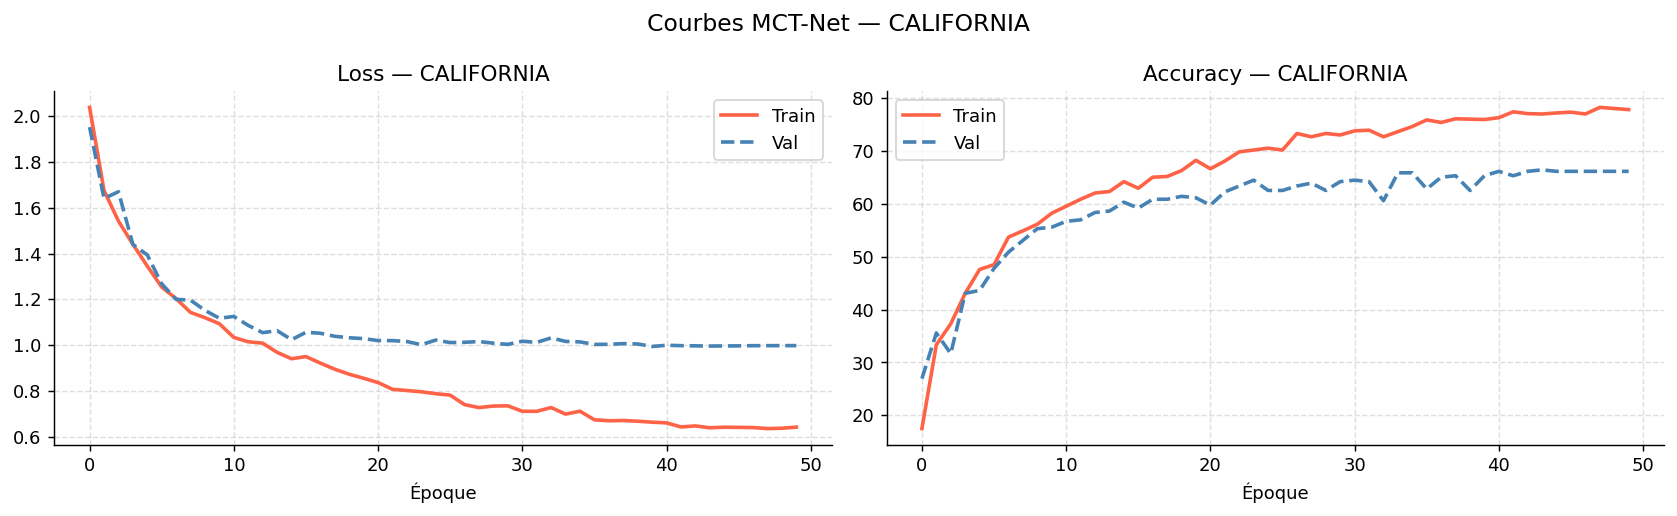

  [CALIFORNIA] Train: Loss=0.6417 Acc=77.78%  |  Val: Loss=0.9979 Acc=66.11%


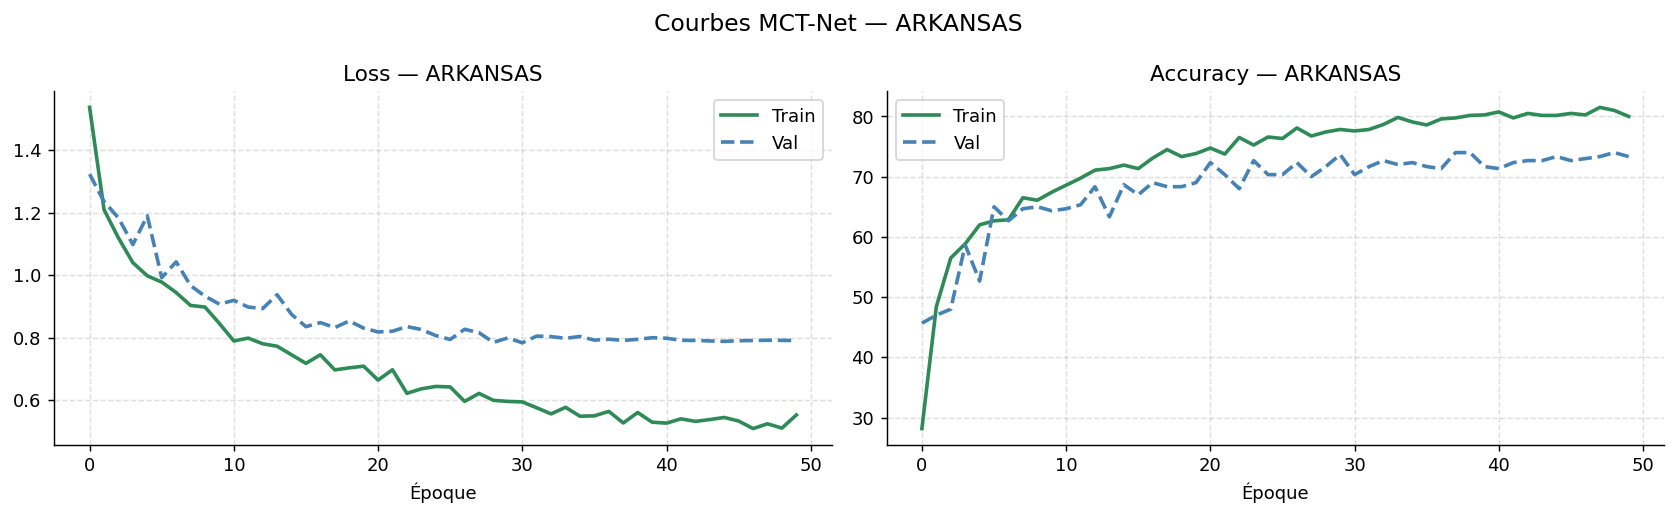

  [ARKANSAS] Train: Loss=0.5529 Acc=80.00%  |  Val: Loss=0.7908 Acc=73.33%


In [15]:
def plot_history(history, label, color='tomato'):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history['loss'],     color=color,      linewidth=2, label='Train')
    axes[0].plot(history['val_loss'], color='steelblue',linewidth=2, label='Val', linestyle='--')
    axes[0].set_title(f'Loss — {label}'); axes[0].set_xlabel('Époque'); axes[0].legend()
    axes[1].plot(history['accuracy'],     color=color,      linewidth=2, label='Train')
    axes[1].plot(history['val_accuracy'], color='steelblue',linewidth=2, label='Val', linestyle='--')
    axes[1].set_title(f'Accuracy — {label}'); axes[1].set_xlabel('Époque'); axes[1].legend()
    plt.suptitle(f'Courbes MCT-Net — {label}', fontsize=13)
    plt.tight_layout(); plt.show()
    print(f'  [{label}] Train: Loss={history["loss"][-1]:.4f} Acc={history["accuracy"][-1]:.2f}%'
          f'  |  Val: Loss={history["val_loss"][-1]:.4f} Acc={history["val_accuracy"][-1]:.2f}%')

plot_history(history_CA, 'CALIFORNIA', color='tomato')
plot_history(history_AR, 'ARKANSAS',   color='seagreen')


### 🧪 Évaluation sur le jeu de TEST

In [16]:
def evaluate_test(model, X_test, y_test, le, device, label):
    model.eval()
    X_t = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_t = torch.tensor(y_test, dtype=torch.long).to(device)
    with torch.no_grad():
        outputs = model(X_t)
        _, predicted = torch.max(outputs, 1)
        acc = 100 * (predicted == y_t).sum().item() / len(y_t)
    print(f'🎯 [{label}] Accuracy TEST : {acc:.2f}%  (classes: {list(le.classes_)})')
    return acc

test_acc_CA = evaluate_test(model_CA, X_test_CA, y_test_CA, le_CA, DEVICE, 'CALIFORNIA')
test_acc_AR = evaluate_test(model_AR, X_test_AR, y_test_AR, le_AR, DEVICE, 'ARKANSAS')


🎯 [CALIFORNIA] Accuracy TEST : 72.68%  (classes: ['Alfalfa', 'Almonds', 'Grapes', 'Others', 'Pistachios', 'Rice'])
🎯 [ARKANSAS] Accuracy TEST : 70.39%  (classes: ['Corn', 'Cotton', 'Others', 'Rice', 'Soybeans'])


### 💾 Sauvegarde du modèle

In [17]:
def save_model(model, path, num_classes, le, history, test_acc, n_dates, label):
    torch.save({
        'model_state_dict': model.state_dict(),
        'num_classes'     : num_classes,
        'label_classes'   : list(le.classes_),
        'history'         : history,
        'test_accuracy'   : test_acc,
        'n_dates'         : n_dates,
        'n_bands'         : N_BANDS,
    }, path)
    print(f'✅ [{label}] Modèle sauvegardé : {path}')
    print(f'   Accuracy test : {test_acc:.2f}%')

save_model(model_CA, MODEL_PATH_CA, num_classes_CA, le_CA, history_CA, test_acc_CA, len(DATES_MAP_CA), 'CALIFORNIA')
save_model(model_AR, MODEL_PATH_AR, num_classes_AR, le_AR, history_AR, test_acc_AR, len(DATES_MAP_AR), 'ARKANSAS')

print('\n🎉 Pipeline MCT-Net complet — California + Arkansas terminé !')


✅ [CALIFORNIA] Modèle sauvegardé : models\mctnet_california_final.pth
   Accuracy test : 72.68%
✅ [ARKANSAS] Modèle sauvegardé : models\mctnet_arkansas_final.pth
   Accuracy test : 70.39%

🎉 Pipeline MCT-Net complet — California + Arkansas terminé !
